<h1> <b> Importing required libraries </b> </h1>

In [ ]:
pip install sqlite3  # Optional, because it's already preinstalled

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import os

<h1> Load the Dataset </h1>

In [72]:
df = pd.read_csv("/content/Dataset.csv")

<h2> Access first Ten rows </h2>

In [5]:
df.head(10)

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,total_sales,city,hour
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",April,23.90,"Dallas, TX",8
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",April,99.99,"Boston, MA",22
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,600.00,"Los Angeles, CA",14
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,11.99,"Los Angeles, CA",14
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",April,11.99,"Los Angeles, CA",9
5,176562,USB-C Charging Cable,1,11.95,2019-04-29 13:03:00,"381 Wilson St, San Francisco, CA 94016",April,11.95,"San Francisco, CA",13
6,176563,Bose SoundSport Headphones,1,99.99,2019-04-02 07:46:00,"668 Center St, Seattle, WA 98101",April,99.99,"Seattle, WA",7
7,176564,USB-C Charging Cable,1,11.95,2019-04-12 10:58:00,"790 Ridge St, Atlanta, GA 30301",April,11.95,"Atlanta, GA",10
8,176565,Macbook Pro Laptop,1,1700.00,2019-04-24 10:38:00,"915 Willow St, San Francisco, CA 94016",April,1700.00,"San Francisco, CA",10
9,176566,Wired Headphones,1,11.99,2019-04-08 14:05:00,"83 7th St, Boston, MA 02215",April,11.99,"Boston, MA",14


<h2> Displaying total columns from Dataset </h2>

In [6]:
df.columns

Index(['order_id', 'product', 'quantity_ordered', 'price_each', 'order_date',
       'purchase_address', 'month', 'total_sales', 'city', 'hour'],
      dtype='object')

<h2> Getting all columns one by one </h2>

In [7]:
for column in df.columns:
    print(column)

order_id
product
quantity_ordered
price_each
order_date
purchase_address
month
total_sales
city
hour


<h2> Checking column types </h2>

In [8]:
df.dtypes

,0
order_id,int64
product,object
quantity_ordered,int64
price_each,float64
order_date,object
purchase_address,object
month,object
total_sales,float64
city,object
hour,int64


<h2> DataFrame information </h2>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182735 entries, 0 to 182734
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          182735 non-null  int64  
 1   product           182735 non-null  object 
 2   quantity_ordered  182735 non-null  int64  
 3   price_each        182735 non-null  float64
 4   order_date        182735 non-null  object 
 5   purchase_address  182735 non-null  object 
 6   month             182735 non-null  object 
 7   total_sales       182735 non-null  float64
 8   city              182735 non-null  object 
 9   hour              182735 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 13.9+ MB


<h2> Checking missing values for each column </h2>

In [10]:
df.isnull()

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,total_sales,city,hour
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
182730,False,False,False,False,False,False,False,False,False,False
182731,False,False,False,False,False,False,False,False,False,False
182732,False,False,False,False,False,False,False,False,False,False
182733,False,False,False,False,False,False,False,False,False,False


<h2> Checking missing values count on each column </h2>

In [11]:
df.isnull().sum()

,0
order_id,0
product,0
quantity_ordered,0
price_each,0
order_date,0
purchase_address,0
month,0
total_sales,0
city,0
hour,0


<h2> Checkcing number of columns </h2>

In [12]:
len(df.columns)

10

In [13]:
df.shape

(182735, 10)

In [14]:
df.dtypes

,0
order_id,int64
product,object
quantity_ordered,int64
price_each,float64
order_date,object
purchase_address,object
month,object
total_sales,float64
city,object
hour,int64


<h2> Converting order_date data type into datatime data type </h2>

In [16]:
df['order_date'] = pd.to_datetime(df.order_date, format='%m/%d/%Y %H:%M')

<h2> Checking type of order_date </h2>

In [17]:
df.dtypes

,0
order_id,int64
product,object
quantity_ordered,int64
price_each,float64
order_date,datetime64[ns]
purchase_address,object
month,object
total_sales,float64
city,object
hour,int64


In [19]:
df.head(10)

,order_id,product,quantity_ordered,price_each,order_date,purchase_address,month,total_sales,city,hour
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",April,23.90,"Dallas, TX",8
1,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",April,99.99,"Boston, MA",22
2,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,600.00,"Los Angeles, CA",14
3,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,11.99,"Los Angeles, CA",14
4,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",April,11.99,"Los Angeles, CA",9
5,176562,USB-C Charging Cable,1,11.95,2019-04-29 13:03:00,"381 Wilson St, San Francisco, CA 94016",April,11.95,"San Francisco, CA",13
6,176563,Bose SoundSport Headphones,1,99.99,2019-04-02 07:46:00,"668 Center St, Seattle, WA 98101",April,99.99,"Seattle, WA",7
7,176564,USB-C Charging Cable,1,11.95,2019-04-12 10:58:00,"790 Ridge St, Atlanta, GA 30301",April,11.95,"Atlanta, GA",10
8,176565,Macbook Pro Laptop,1,1700.00,2019-04-24 10:38:00,"915 Willow St, San Francisco, CA 94016",April,1700.00,"San Francisco, CA",10
9,176566,Wired Headphones,1,11.99,2019-04-08 14:05:00,"83 7th St, Boston, MA 02215",April,11.99,"Boston, MA",14


<h2> Description </h2>

In [20]:
print(df.describe(include='all'))

             order_id               product  quantity_ordered     price_each  \
count   182735.000000                182735     182735.000000  182735.000000   
unique            NaN                    19               NaN            NaN   
top               NaN  USB-C Charging Cable               NaN            NaN   
freq              NaN                 21523               NaN            NaN   
mean    230533.878463                   NaN          1.124333     184.315392   
min     141234.000000                   NaN          1.000000       2.990000   
25%     185954.500000                   NaN          1.000000      11.950000   
50%     230485.000000                   NaN          1.000000      14.950000   
75%     275220.500000                   NaN          1.000000     150.000000   
max     319670.000000                   NaN          9.000000    1700.000000   
std      51543.205104                   NaN          0.442937     332.684344   

                           order_date  

<h2> Filter required columns </h2>

In [21]:
df = df[['product', 'quantity_ordered', 'price_each', 'total_sales']]

<h2> Drop missing values </h2>

In [22]:
df.dropna(inplace=True)

<h2> Rename columns for SQL ease </h2>

In [84]:
df.rename(columns={
    'quantity_ordered': 'quantity',
    'price_each': 'price',
}, inplace=True)

In [24]:
df.head()

,product,quantity,price,total_sales
0,USB-C Charging Cable,2,11.95,23.90
1,Bose SoundSport Headphones,1,99.99,99.99
2,Google Phone,1,600.00,600.00
3,Wired Headphones,1,11.99,11.99
4,Wired Headphones,1,11.99,11.99


<h2> Ensure correct data types </h2>

In [25]:
df['quantity'] = df['quantity'].astype(int)
df['price'] = df['price'].astype(float)
df['total_sales'] = df['total_sales'].astype(float)

In [26]:
df.dtypes

,0
product,object
quantity,int64
price,float64
total_sales,float64


<h1> <b> Create SQLite database </b> </h1>

In [61]:
conn = sqlite3.connect("/content/Dataset.db")

<h2> Save to database </h2>

In [33]:
df.to_sql("sales", conn, if_exists='replace', index=False)

182735

<h1> SQL Query for Sales Summary </h1>

In [35]:
query = """
SELECT
    product,
    SUM(quantity) AS total_qty,
    ROUND(SUM(total_sales), 2) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC
"""
summary_df = pd.read_sql_query(query, conn)
print(summary_df)

                       product  total_qty     revenue
0           Macbook Pro Laptop       4645  7896500.00
1                       iPhone       6732  4712400.00
2              ThinkPad Laptop       4054  4053959.46
3                 Google Phone       5440  3264000.00
4       27in 4K Gaming Monitor       6134  2392198.66
5       34in Ultrawide Monitor       6076  2308819.24
6     Apple Airpods Headphones      15383  2307450.00
7                Flatscreen TV       4724  1417200.00
8   Bose SoundSport Headphones      13236  1323467.64
9             27in FHD Monitor       7429  1114275.71
10             Vareebadd Phone       2023   809200.00
11                20in Monitor       4058   446339.42
12          LG Washing Machine        649   389400.00
13                    LG Dryer        640   384000.00
14    Lightning Charging Cable      22841   341472.95
15        USB-C Charging Cable      23555   281482.25
16            Wired Headphones      20201   242209.99
17       AA Batteries (4-pac

<h2>  Bar Chart — Revenue per Product </h2>

<Figure size 1000x600 with 0 Axes>

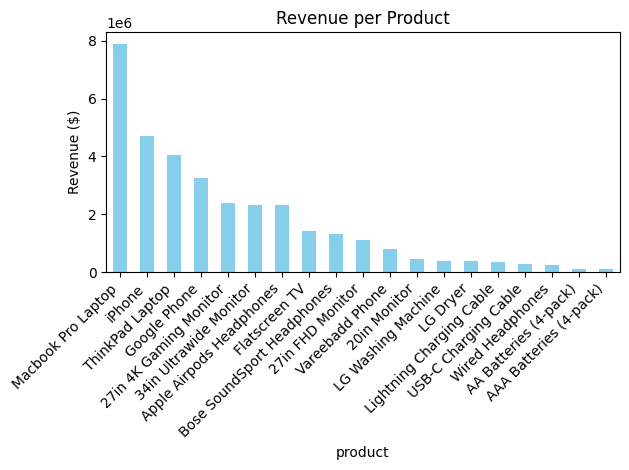

In [68]:
plt.figure(figsize=(10, 6))
summary_df.plot(kind='bar', x='product', y='revenue', color='skyblue', legend=False)
plt.title("Revenue per Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("Revenue_per_Product.png")
plt.show()

<h1> <b>Optional Section: Add a Few More Graphs</b> </h1>

<h2> Total Quantity per Product </h2>

<Figure size 1000x600 with 0 Axes>

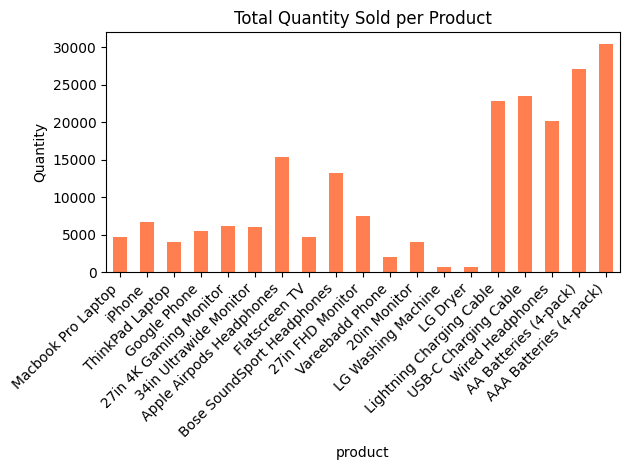

In [41]:
plt.figure(figsize=(10, 6))
summary_df.plot(kind='bar', x='product', y='total_qty', color='coral', legend=False)
plt.title("Total Quantity Sold per Product")
plt.ylabel("Quantity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("quantity_chart.png")
plt.show()

<h2> Time-Based Sales Trend </h2>

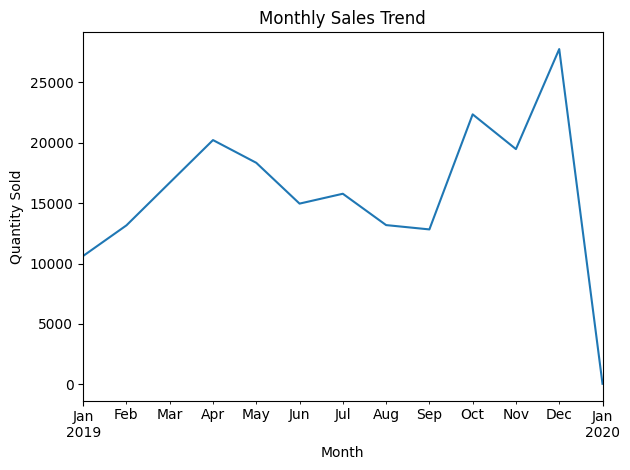

In [86]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['quantity'].sum()
monthly_sales.plot(kind='line', title="Monthly Sales Trend")
plt.ylabel("Quantity Sold")
plt.xlabel("Month")
plt.tight_layout()
plt.savefig("monthly_sales_trend.png")
plt.show()

<h2>  Revenue vs Quantity </h2>

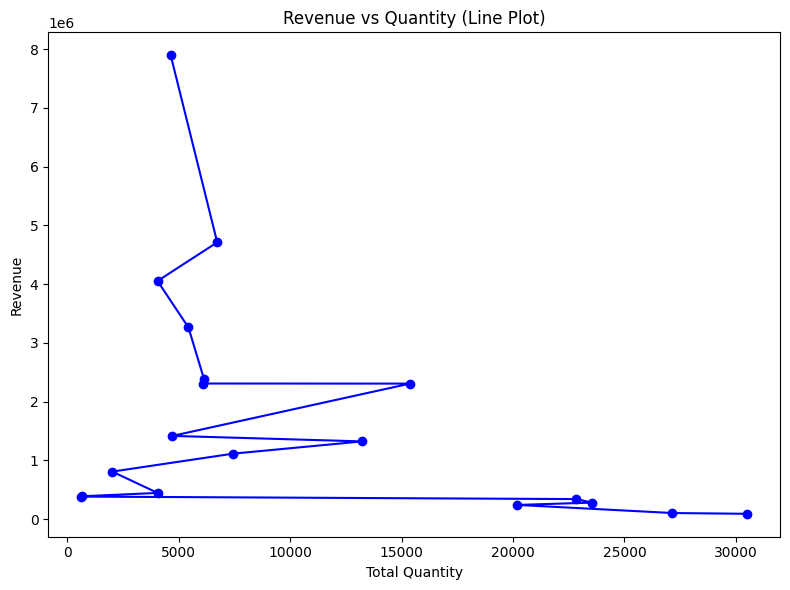

In [45]:
plt.figure(figsize=(8, 6))
plt.plot(summary_df['total_qty'], summary_df['revenue'], color='blue', marker='o')
plt.title("Revenue vs Quantity (Line Plot)")
plt.xlabel("Total Quantity")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("revenue_vs_quantity_line_plot.png")
plt.show()


<h2> Top 5 Revenue Share </h2>

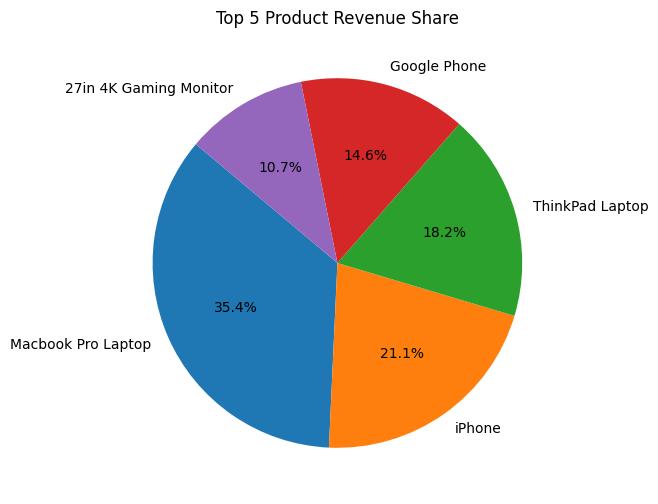

In [79]:
top5 = summary_df.head(5)
plt.figure(figsize=(6, 6))
plt.pie(top5['revenue'], labels=top5['product'], autopct='%1.1f%%', startangle=140)
plt.title("Top 5 Product Revenue Share")
plt.savefig("top5_pie.png")
plt.show()

<h2> Quantity Sold by City </h2>

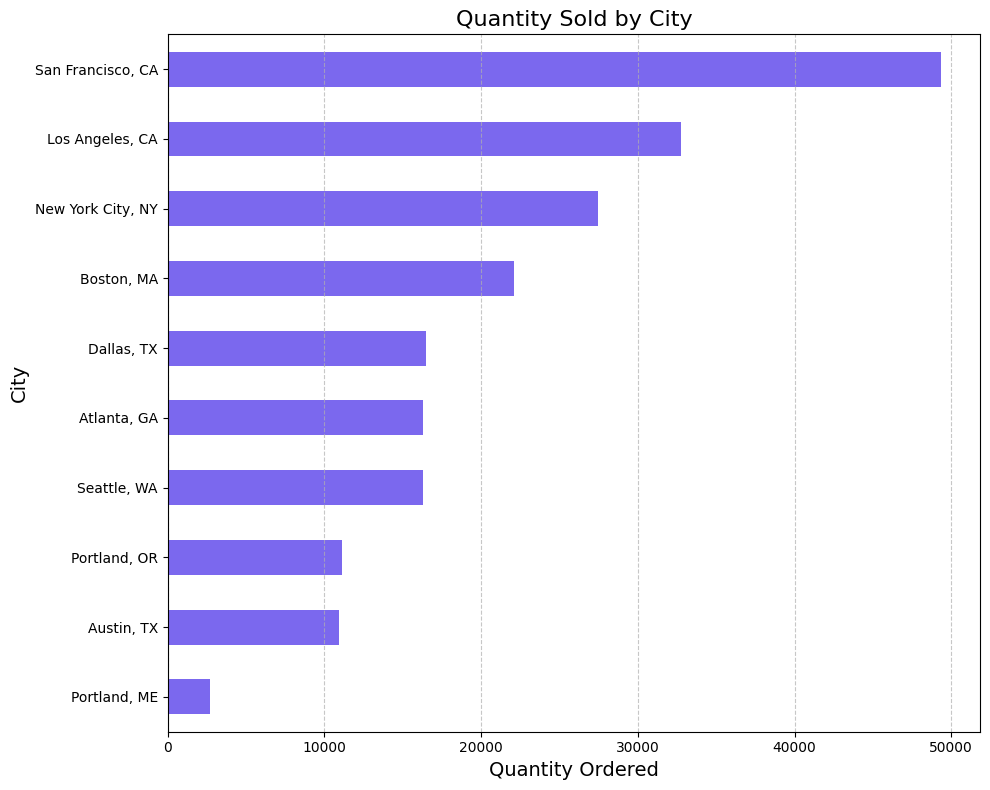

In [87]:


city_quantity = df.groupby('city')['quantity'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
city_quantity.plot(kind='barh', color='mediumslateblue')
plt.title("Quantity Sold by City", fontsize=16)
plt.xlabel("Quantity Ordered", fontsize=14)
plt.ylabel("City", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("quantity_sold_by_city.png")
plt.show()


<h2> Price Distribution </h2>

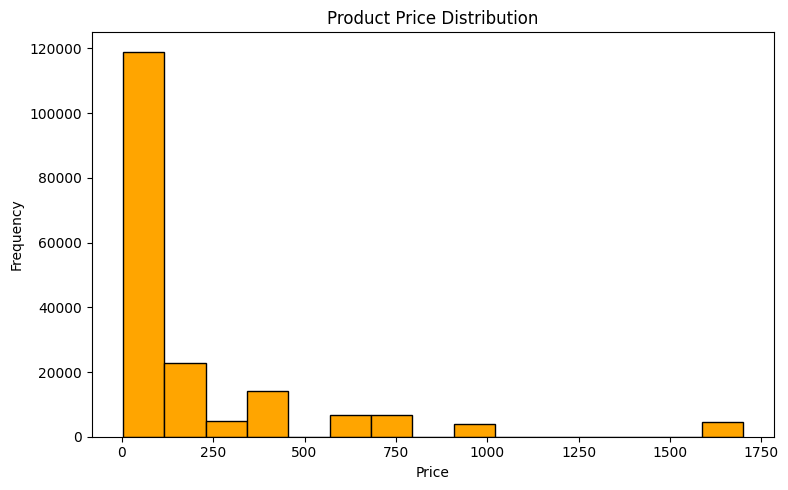

In [50]:
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=15, color='orange', edgecolor='black')
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("price_histogram.png")
plt.show()

<h2> Cumulative Revenue </h2>

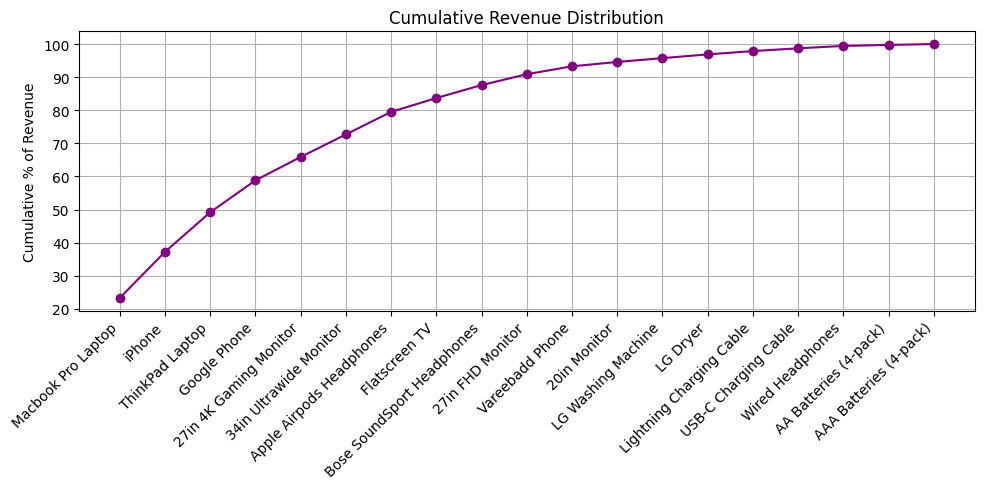

In [51]:
summary_df['cumulative_revenue'] = summary_df['revenue'].cumsum()
summary_df['cumulative_percent'] = 100 * summary_df['cumulative_revenue'] / summary_df['revenue'].sum()

plt.figure(figsize=(10, 5))
plt.plot(summary_df['product'], summary_df['cumulative_percent'], marker='o', color='purple')
plt.title("Cumulative Revenue Distribution")
plt.ylabel("Cumulative % of Revenue")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.savefig("cumulative_revenue.png")
plt.show()


<h1> <b> Export and Clean Up </b> </h1>

<h2> Export summary to CSV </h2>

In [52]:
summary_df.to_csv("summary_all_data.csv", index=False)

<h1> <b> Close connection </b> </h1>

In [88]:
conn.close()

In [89]:
try:
    conn.execute('SELECT 1')
    print("The connection is still open.")
except sqlite3.ProgrammingError:
    print("The connection is closed.")

The connection is closed.
